In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, average_precision_score,
    precision_recall_curve, matthews_corrcoef
)

import warnings
warnings.filterwarnings('ignore')


# ── Load Dataset ─────────────────────────────────────────────

df = pd.read_csv('/kaggle/input/datasets/soura125/api-sla-violation/Final_Topology_Dataset_FULL_0_to_5__2.csv')

df = df.sort_values('time_window').reset_index(drop=True)

X = df.drop(columns=['um','dm','time_window','violation_next_window']) \
      .replace([np.inf,-np.inf],np.nan) \
      .fillna(0)

y = df['violation_next_window']

print(f"Dataset   : {df.shape}")
print(f"Violation : {y.mean():.2%}")


# ── Temporal Split (NO SHUFFLE) ──────────────────────────────

n = len(X)

split1 = int(n * 0.95)
split2 = int(split1 * 0.80)

X_train,  y_train  = X.iloc[:split2],       y.iloc[:split2]
X_test,   y_test   = X.iloc[split2:split1], y.iloc[split2:split1]
X_unseen, y_unseen = X.iloc[split1:],       y.iloc[split1:]

print("\nTemporal Split:")
print(f"Train  : {len(X_train)} rows")
print(f"Test   : {len(X_test)} rows")
print(f"Unseen : {len(X_unseen)} rows")


# ── TimeSeries Cross Validation ─────────────────────────────

tscv = TimeSeriesSplit(n_splits=3)


# ── Random Forest Hyperparameter Search ─────────────────────

rf_tuner = RandomizedSearchCV(

    RandomForestClassifier(random_state=42),

    param_distributions = {

        'n_estimators'      : [100, 200, 300],
        'max_depth'         : [10, 20, 30],   # ❌ removed None
        'min_samples_split' : [2, 5, 10],
        'min_samples_leaf'  : [1, 2, 4],
        'class_weight'      : ['balanced', 'balanced_subsample']
    },

    n_iter       = 10,
    scoring      = 'f1',
    cv           = tscv,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 1
)


print(f"\nTraining Random Forest on {len(X_train)} rows...")
rf_tuner.fit(X_train, y_train)

best_rf = rf_tuner.best_estimator_

print("\nBest Parameters:", rf_tuner.best_params_)
print(f"Best CV F1 : {rf_tuner.best_score_:.4f}")


# ── Threshold Optimization ──────────────────────────────────

y_prob_test = best_rf.predict_proba(X_test)[:,1]

pre, rec, thr = precision_recall_curve(y_test, y_prob_test)

f1_thr = 2 * pre * rec / (pre + rec + 1e-9)

best_thr = thr[np.argmax(f1_thr[:-1])]

print(f"\nOptimal Threshold : {best_thr:.4f}")


# ── Predictions ─────────────────────────────────────────────

y_prob_unseen = best_rf.predict_proba(X_unseen)[:,1]

y_pred_test   = (y_prob_test   >= best_thr).astype(int)
y_pred_unseen = (y_prob_unseen >= best_thr).astype(int)

cm_rf = confusion_matrix(y_unseen, y_pred_unseen)


# ── Test Set Evaluation ─────────────────────────────────────

print("\n── TEST SET ─────────────────────────")

print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Normal','Violation']
))

print(f"Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_test):.4f}")


# ── Unseen Set Evaluation ───────────────────────────────────

print("\n── UNSEEN SET ───────────────────────")

print(classification_report(
    y_unseen,
    y_pred_unseen,
    target_names=['Normal','Violation']
))

print(f"Balanced Accuracy : {balanced_accuracy_score(y_unseen, y_pred_unseen):.4f}")
print(f"F1 (violations)   : {f1_score(y_unseen, y_pred_unseen):.4f}")

print(f"Caught : {cm_rf[1][1]}/{cm_rf[1].sum()} ({cm_rf[1][1]/cm_rf[1].sum():.1%})")
print(f"Missed : {cm_rf[1][0]}/{cm_rf[1].sum()} ({cm_rf[1][0]/cm_rf[1].sum():.1%})")


# ── Full Metrics Function ───────────────────────────────────

def full_metrics(y_true, y_pred, y_prob, split_name):

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    return {

        'Split'            : split_name,
        'Precision'        : round(precision_score(y_true, y_pred, zero_division=0),4),
        'Recall'           : round(recall_score(y_true, y_pred, zero_division=0),4),
        'F1 Score'         : round(f1_score(y_true, y_pred, zero_division=0),4),
        'Balanced Accuracy': round(balanced_accuracy_score(y_true, y_pred),4),
        'Accuracy'         : round((tp+tn)/(tp+tn+fp+fn),4),
        'AUC-ROC'          : round(roc_auc_score(y_true, y_prob),4),
        'AUC-PR'           : round(average_precision_score(y_true, y_prob),4),

        'TP (Caught)'      : int(tp),
        'FN (Missed)'      : int(fn),
        'FP (False Alarm)' : int(fp),
        'TN (True Normal)' : int(tn),

        'Catch Rate'       : f"{tp/(tp+fn)*100:.1f}%",
        'Miss Rate'        : f"{fn/(tp+fn)*100:.1f}%",
        'False Alarm Rate' : f"{fp/(fp+tn)*100:.1f}%",

        'MCC'              : round(matthews_corrcoef(y_true, y_pred),4),
        'Total Violations' : int(tp+fn)
    }


rows = [

    full_metrics(y_test,   y_pred_test,   y_prob_test,   'Test Set'),
    full_metrics(y_unseen, y_pred_unseen, y_prob_unseen, 'Unseen Set')

]

summary_df = pd.DataFrame(rows)


# ── Final Report ────────────────────────────────────────────

print("\n" + "="*65)
print(" RANDOM FOREST — FINAL METRICS REPORT")
print(" SLA Violation Prediction")
print("="*65)

groups = {

    'CORE METRICS' : [
        'Precision','Recall','F1 Score',
        'Balanced Accuracy','Accuracy'
    ],

    'CURVE SCORES' : [
        'AUC-ROC','AUC-PR'
    ],

    'CONFUSION MATRIX' : [
        'TP (Caught)','FN (Missed)',
        'FP (False Alarm)','TN (True Normal)'
    ],

    'RATES' : [
        'Catch Rate','Miss Rate','False Alarm Rate'
    ],

    'EXTRA' : [
        'MCC','Total Violations'
    ]
}


for group, cols in groups.items():

    print(f"\n── {group} {'─'*(48-len(group))}")

    print(summary_df[['Split'] + cols].to_string(index=False))


# ── Save Report ─────────────────────────────────────────────

summary_df.to_csv('/kaggle/working/rf_final_report.csv', index=False)

print("\nSaved → /kaggle/working/rf_final_report.csv")

Dataset   : (178930, 48)
Violation : 5.13%

Temporal Split:
Train  : 135986 rows
Test   : 33997 rows
Unseen : 8947 rows

Training Random Forest on 135986 rows...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30, 'class_weight': 'balanced_subsample'}
Best CV F1 : 0.7099

Optimal Threshold : 0.5684

── TEST SET ─────────────────────────
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99     32235
   Violation       0.74      0.72      0.73      1762

    accuracy                           0.97     33997
   macro avg       0.86      0.85      0.86     33997
weighted avg       0.97      0.97      0.97     33997

Balanced Accuracy : 0.8512

── UNSEEN SET ───────────────────────
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      8447
   Violation       0.76      0.73      0.74   

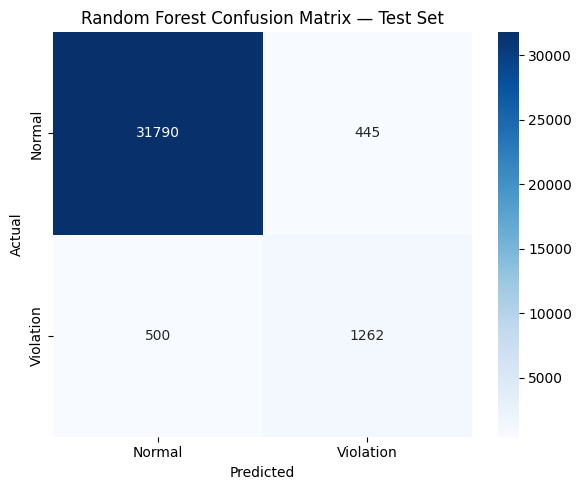

1. Confusion Matrix (Test) saved.


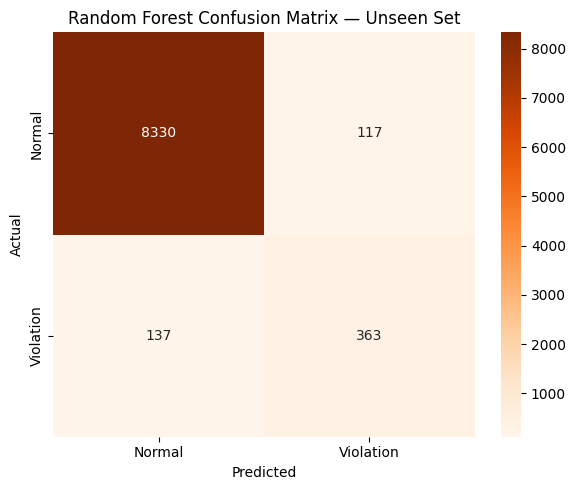

2. Confusion Matrix (Unseen) saved.


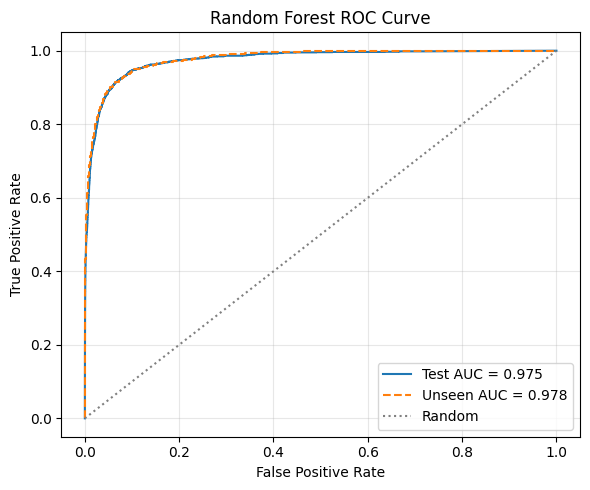

3. ROC Curve saved.


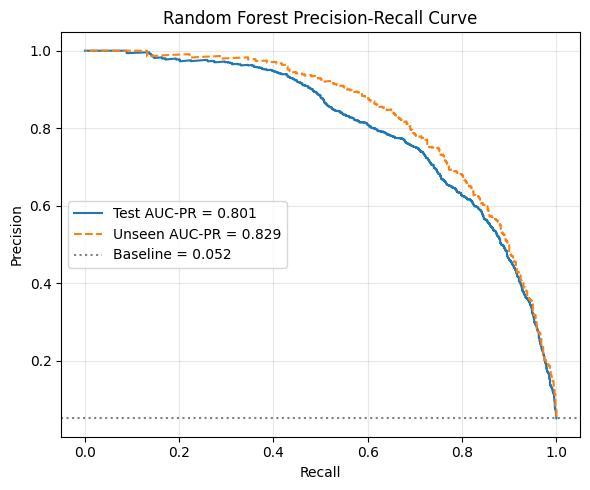

4. Precision-Recall Curve saved.


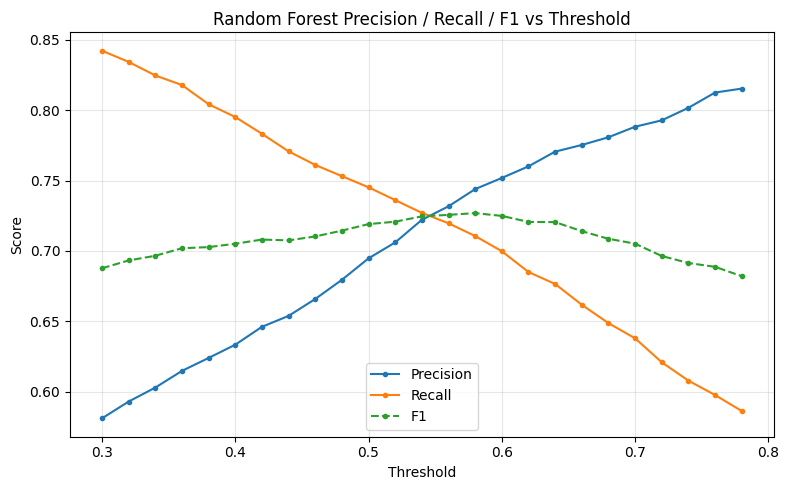

5. Threshold Metrics saved.

Calculating permutation importance...

Top 20 Feature Importances:
             Feature  Importance      Std
         p95_trend_5    0.064461 0.003865
         p95_latency    0.040147 0.002616
         p95_trend_3    0.034361 0.002069
         max_latency    0.014515 0.001809
            prev_p95    0.007863 0.002051
           dm_ms_cpu    0.002701 0.000946
        mean_latency    0.001694 0.002731
          dm_http_rt    0.001377 0.001108
         dm_http_mcr    0.001275 0.000634
       dm_writedb_rt    0.000922 0.000929
   um_consumerrpc_rt    0.000710 0.000693
        dm_readdb_rt    0.000668 0.001045
       latency_delta    0.000603 0.001180
           um_ms_mem    0.000468 0.000331
   dm_providerrpc_rt    0.000460 0.000799
           um_ms_cpu    0.000374 0.000716
dm_physical_node_cpu    0.000369 0.001124
         um_http_mcr    0.000350 0.000574
   dm_consumerrpc_rt    0.000309 0.001145
       um_writedb_rt    0.000264 0.000350


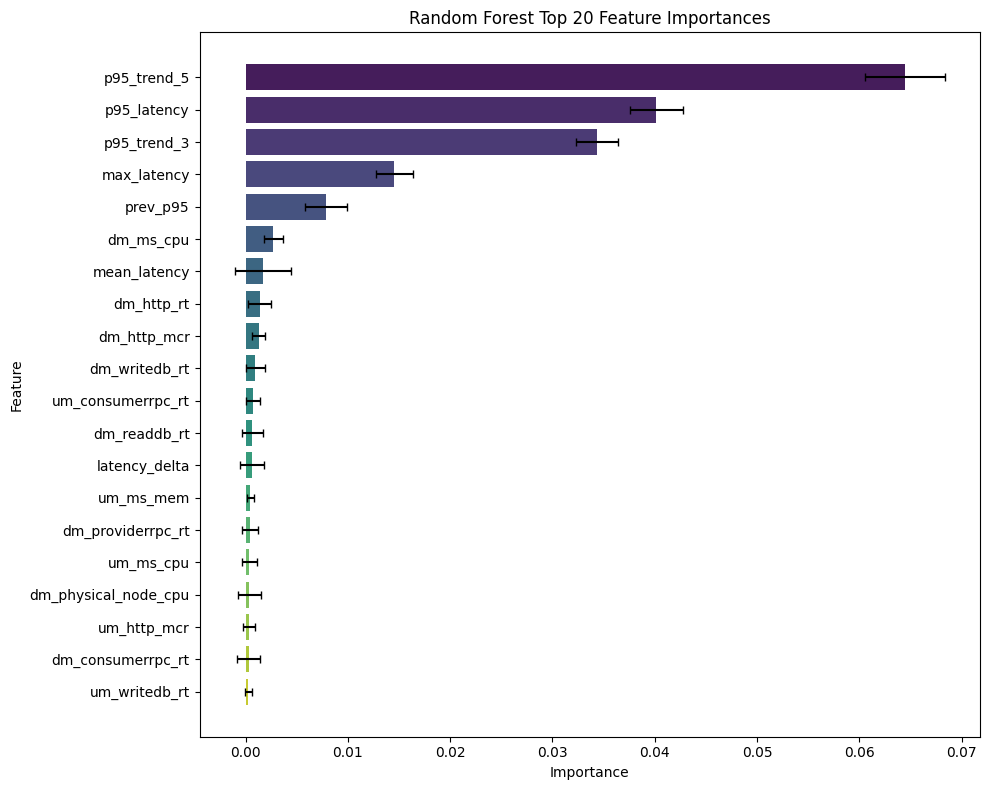

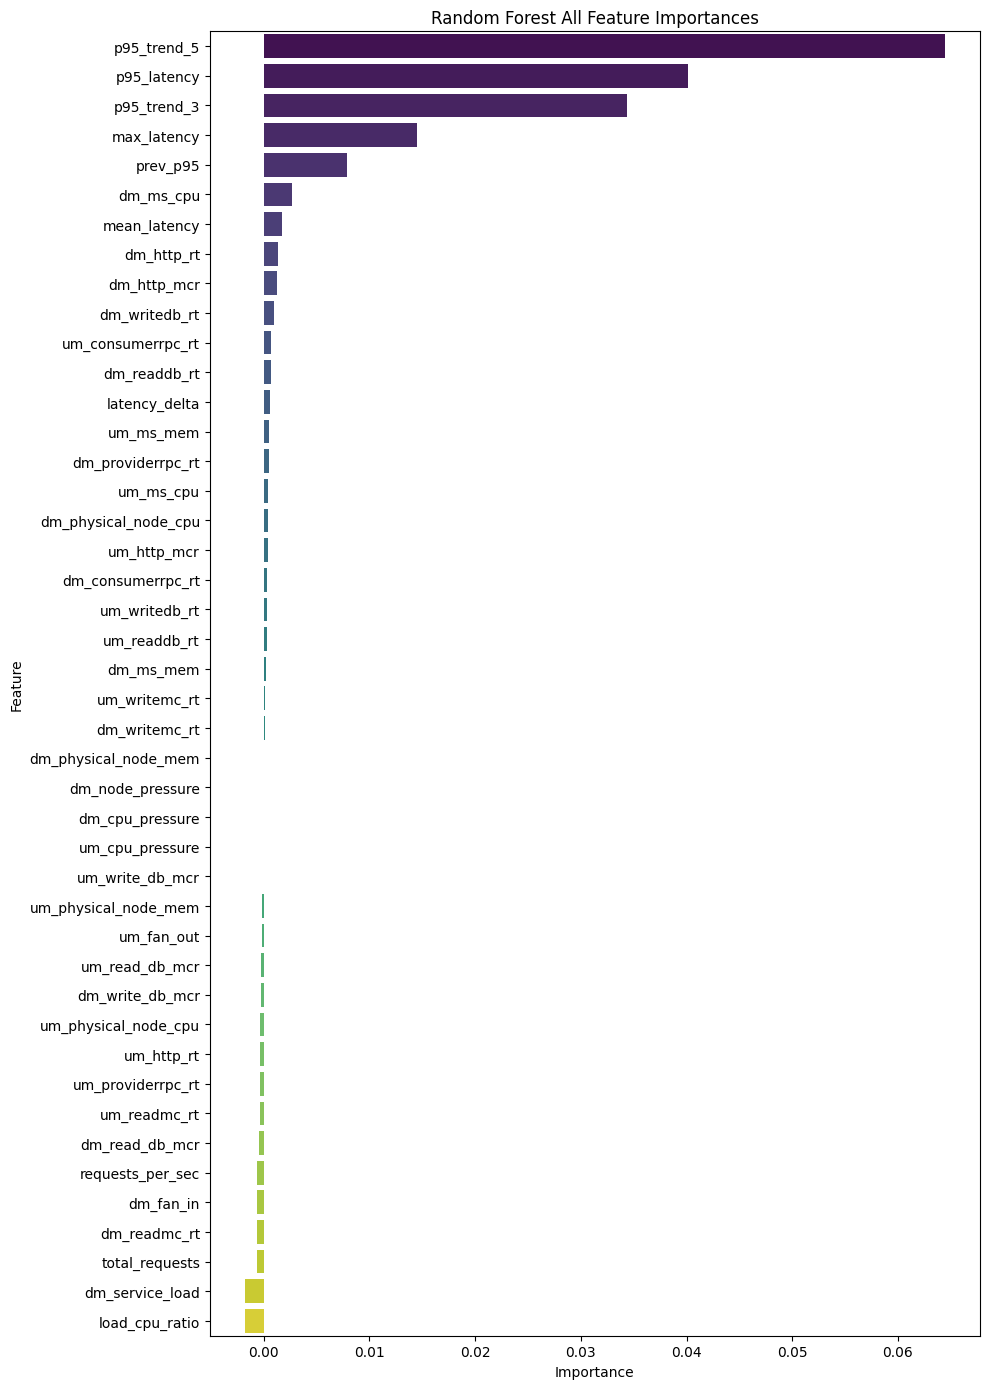

6. Feature Importance saved.

Generating learning curve...


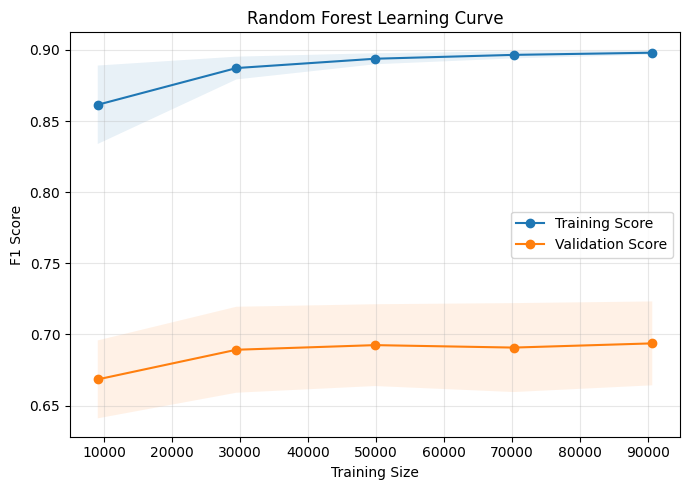

7. Learning Curve saved.


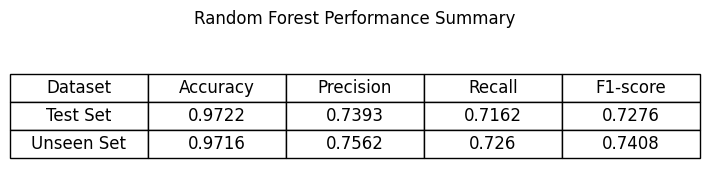


8. Performance Summary saved.

   Dataset  Accuracy  Precision  Recall  F1-score
  Test Set    0.9722     0.7393  0.7162    0.7276
Unseen Set    0.9716     0.7562  0.7260    0.7408

All graphs saved to: /kaggle/working/RF_45features_results

Files saved:
  rf_confusion_matrix_test.png  —  41.11 KB
  rf_confusion_matrix_unseen.png  —  42.76 KB
  rf_feature_importance_all.png  —  156.61 KB
  rf_feature_importance_top20.png  —  82.99 KB
  rf_learning_curve.png  —  49.89 KB
  rf_performance_summary.png  —  31.94 KB
  rf_precision_recall_curve.png  —  59.32 KB
  rf_roc_curve.png  —  57.81 KB
  rf_threshold_metrics.png  —  77.85 KB


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve


# =================================================
# SETUP
# =================================================

save_path = "/kaggle/working/RF_45features_results"
os.makedirs(save_path, exist_ok=True)


# =================================================
# 1. CONFUSION MATRIX — Test Set
# =================================================

cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Violation'],
    yticklabels=['Normal', 'Violation']
)

plt.title("Random Forest Confusion Matrix — Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(f"{save_path}/rf_confusion_matrix_test.png", dpi=150)
plt.show()

print("1. Confusion Matrix (Test) saved.")


# =================================================
# 2. CONFUSION MATRIX — Unseen Set
# =================================================

cm_unseen = confusion_matrix(y_unseen, y_pred_unseen)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_unseen, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Normal', 'Violation'],
    yticklabels=['Normal', 'Violation']
)

plt.title("Random Forest Confusion Matrix — Unseen Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(f"{save_path}/rf_confusion_matrix_unseen.png", dpi=150)
plt.show()

print("2. Confusion Matrix (Unseen) saved.")


# =================================================
# 3. ROC CURVE
# =================================================

fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_test)
fpr_u, tpr_u, _ = roc_curve(y_unseen, y_prob_unseen)

auc_t = auc(fpr_t, tpr_t)
auc_u = auc(fpr_u, tpr_u)

plt.figure(figsize=(6, 5))

plt.plot(fpr_t, tpr_t, label=f"Test AUC = {auc_t:.3f}")
plt.plot(fpr_u, tpr_u, linestyle="--", label=f"Unseen AUC = {auc_u:.3f}")

plt.plot([0,1],[0,1], linestyle=":", color="gray", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{save_path}/rf_roc_curve.png", dpi=150)
plt.show()

print("3. ROC Curve saved.")


# =================================================
# 4. PRECISION-RECALL CURVE
# =================================================

pre_t, rec_t, _ = precision_recall_curve(y_test, y_prob_test)
pre_u, rec_u, _ = precision_recall_curve(y_unseen, y_prob_unseen)

pr_auc_t = average_precision_score(y_test, y_prob_test)
pr_auc_u = average_precision_score(y_unseen, y_prob_unseen)

plt.figure(figsize=(6, 5))

plt.plot(rec_t, pre_t, label=f"Test AUC-PR = {pr_auc_t:.3f}")
plt.plot(rec_u, pre_u, linestyle="--", label=f"Unseen AUC-PR = {pr_auc_u:.3f}")

plt.axhline(
    y_test.mean(),
    linestyle=":",
    color="gray",
    label=f"Baseline = {y_test.mean():.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Random Forest Precision-Recall Curve")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{save_path}/rf_precision_recall_curve.png", dpi=150)
plt.show()

print("4. Precision-Recall Curve saved.")


# =================================================
# 5. PRECISION / RECALL / F1 vs THRESHOLD
# =================================================

thresholds_plot = np.arange(0.30, 0.80, 0.02)

p_list = []
r_list = []
f_list = []

for t in thresholds_plot:

    preds = (y_prob_test >= t).astype(int)

    p_list.append(precision_score(y_test, preds, zero_division=0))
    r_list.append(recall_score(y_test, preds, zero_division=0))
    f_list.append(f1_score(y_test, preds, zero_division=0))

plt.figure(figsize=(8, 5))

plt.plot(thresholds_plot, p_list, marker='.', label="Precision")
plt.plot(thresholds_plot, r_list, marker='.', label="Recall")
plt.plot(thresholds_plot, f_list, marker='.', linestyle="--", label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("Random Forest Precision / Recall / F1 vs Threshold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{save_path}/rf_threshold_metrics.png", dpi=150)
plt.show()

print("5. Threshold Metrics saved.")


# =================================================
# 6. FEATURE IMPORTANCE (Permutation)
# =================================================

print("\nCalculating permutation importance...")

perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

fi_df = pd.DataFrame({
    "Feature": X.columns.tolist(),
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=False)

print("\nTop 20 Feature Importances:")
print(fi_df.head(20).to_string(index=False))


top20 = fi_df.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top20,
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.errorbar(
    x=top20["Importance"],
    y=range(len(top20)),
    xerr=top20["Std"],
    fmt='none',
    color='black',
    capsize=3
)

plt.title("Random Forest Top 20 Feature Importances")
plt.tight_layout()

plt.savefig(f"{save_path}/rf_feature_importance_top20.png", dpi=150)
plt.show()


plt.figure(figsize=(10, 14))

sns.barplot(
    x="Importance",
    y="Feature",
    data=fi_df,
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Random Forest All Feature Importances")
plt.tight_layout()

plt.savefig(f"{save_path}/rf_feature_importance_all.png", dpi=150)
plt.show()

print("6. Feature Importance saved.")


# =================================================
# 7. LEARNING CURVE
# =================================================

print("\nGenerating learning curve...")

train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)

val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(7, 5))

plt.plot(train_sizes, train_mean, label="Training Score", marker='o')
plt.plot(train_sizes, val_mean, label="Validation Score", marker='o')

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.1
)

plt.xlabel("Training Size")
plt.ylabel("F1 Score")

plt.title("Random Forest Learning Curve")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{save_path}/rf_learning_curve.png", dpi=150)
plt.show()

print("7. Learning Curve saved.")


# =================================================
# 8. PERFORMANCE SUMMARY TABLE
# =================================================

summary_df = pd.DataFrame({

    "Dataset": ["Test Set", "Unseen Set"],

    "Accuracy":[
        round(accuracy_score(y_test, y_pred_test),4),
        round(accuracy_score(y_unseen, y_pred_unseen),4)
    ],

    "Precision":[
        round(precision_score(y_test, y_pred_test),4),
        round(precision_score(y_unseen, y_pred_unseen),4)
    ],

    "Recall":[
        round(recall_score(y_test, y_pred_test),4),
        round(recall_score(y_unseen, y_pred_unseen),4)
    ],

    "F1-score":[
        round(f1_score(y_test, y_pred_test),4),
        round(f1_score(y_unseen, y_pred_unseen),4)
    ]

})

fig, ax = plt.subplots(figsize=(8, 2))

ax.axis('off')

table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)

plt.title("Random Forest Performance Summary", pad=20)

plt.tight_layout()

plt.savefig(f"{save_path}/rf_performance_summary.png", dpi=150)

plt.show()

print("\n8. Performance Summary saved.")
print("\n" + "="*50)
print(summary_df.to_string(index=False))
print("="*50)


# =================================================
# 9. FINISHED
# =================================================

print("\nAll graphs saved to:", save_path)

print("\nFiles saved:")

for f in sorted(os.listdir(save_path)):

    size = os.path.getsize(f"{save_path}/{f}")

    print(f"  {f}  —  {round(size/1024,2)} KB")